In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [40]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

dados = fetch_california_housing(as_frame=True)
df = dados.frame

In [41]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [44]:
# Renomeando as colunas para português do Brasil
df.rename(columns={
    'MedInc': 'renda_mediana',
    'HouseAge': 'idade_imovel',
    'AveRooms': 'media_comodos',
    'AveBedrms': 'media_quartos',
    'Population': 'populacao',
    'AveOccup': 'media_ocupantes',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'MedHouseVal': 'valor_mediano_imovel'
}, inplace=True)
# df.head()
df

,renda_mediana,idade_imovel,media_comodos,media_quartos,populacao,media_ocupantes,latitude,longitude,valor_mediano_imovel
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


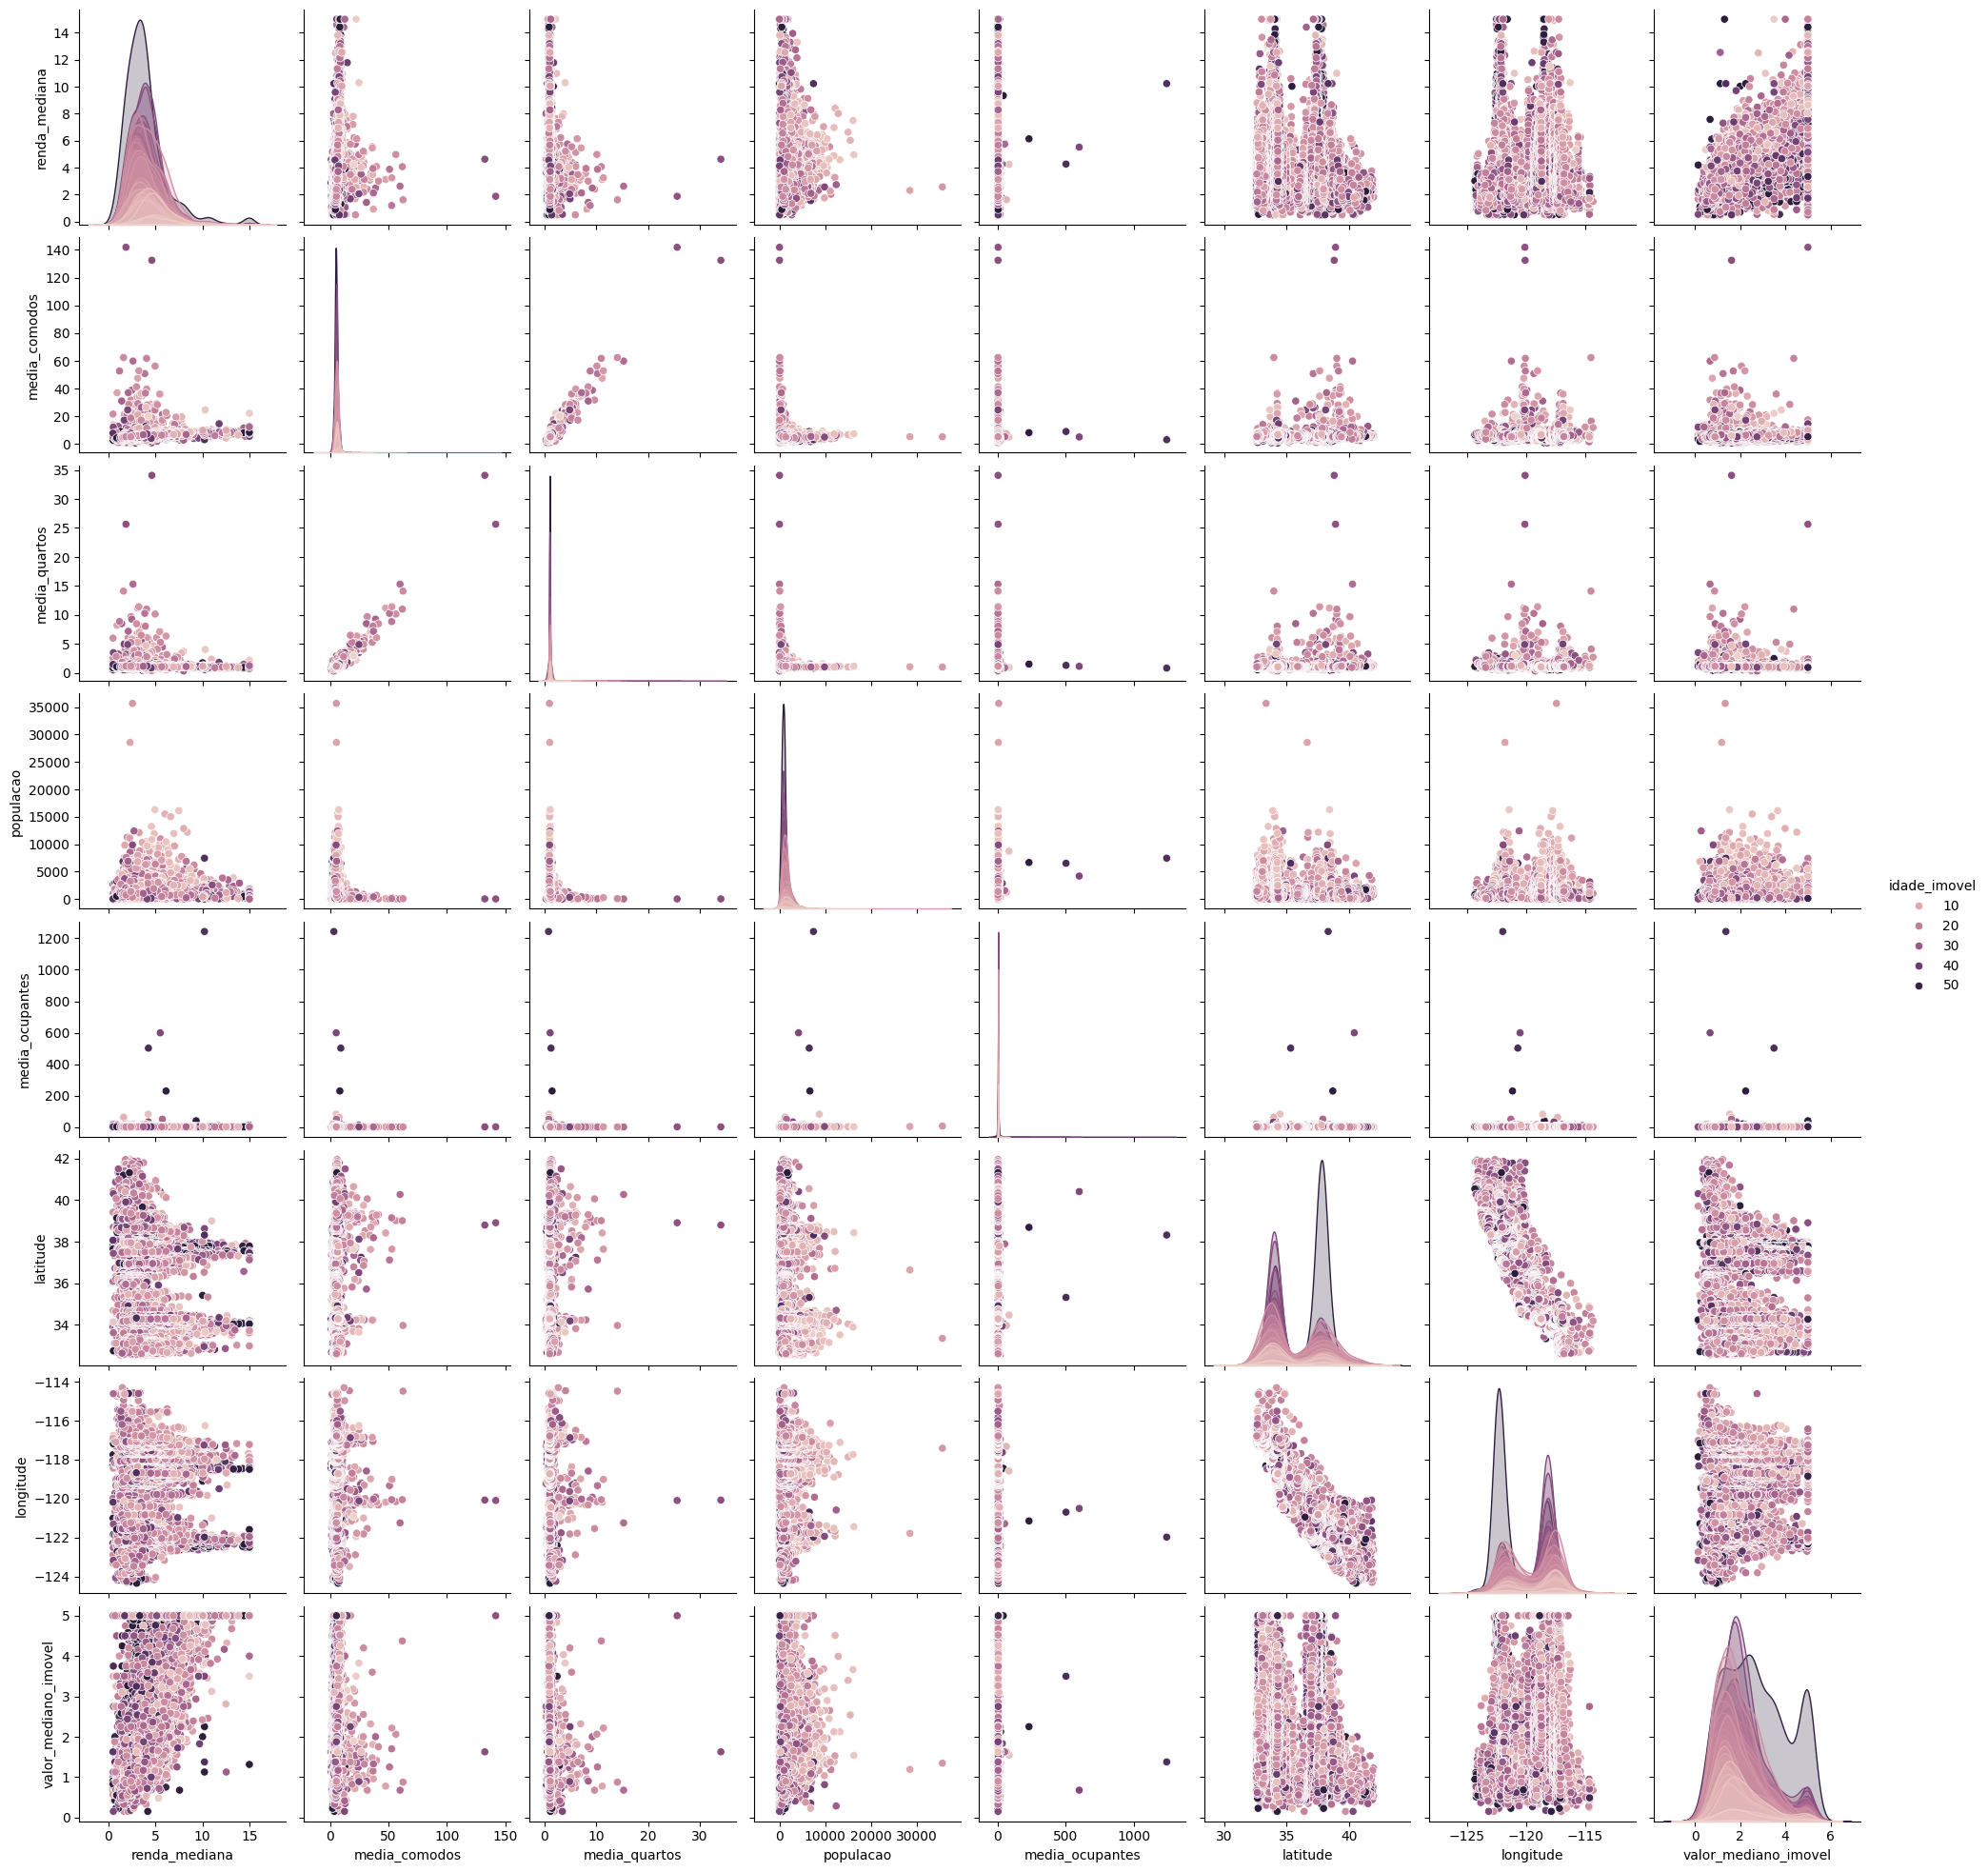

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='idade_imovel')
plt.show()

In [ ]:
Criar um modelo de regressão linear para prever o preço médio das casas (MedHouseVal) em regiões da Califórnia, com base em variáveis como:

número médio de quartos,
população da região,
renda média,
entre outras.

In [67]:
df.corr()

,renda_mediana,idade_imovel,media_comodos,media_quartos,populacao,media_ocupantes,latitude,longitude,valor_mediano_imovel
renda_mediana,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
idade_imovel,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
media_comodos,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
media_quartos,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
populacao,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
media_ocupantes,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
valor_mediano_imovel,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


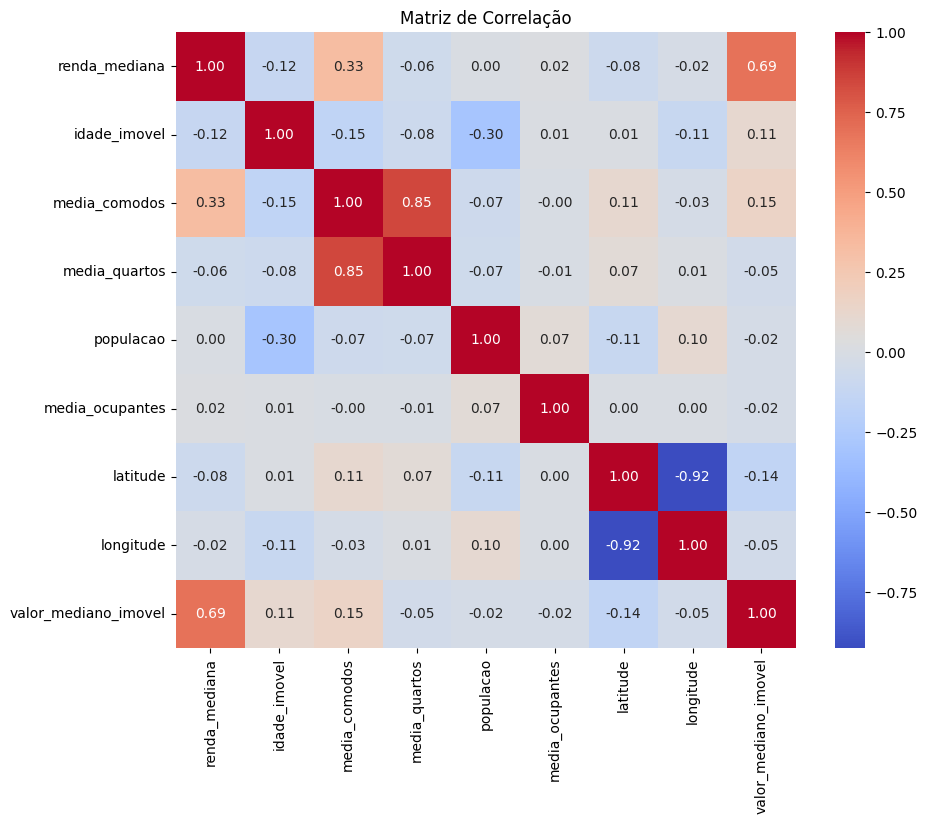

In [68]:
# Matriz de correlação colorida
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()


In [75]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
scaler = StandardScaler()
X = df[['renda_mediana', 'idade_imovel', 'media_comodos', 'media_quartos', 'populacao', 'media_ocupantes', 'latitude', 'longitude']].values

# X =  df[['renda_mediana', 'media_comodos', 'media_quartos', 'latitude', 'longitude']]
X = scaler.fit_transform(X)

y = df[['valor_mediano_imovel']].values
display(y, X)


# Separação dos dados
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#  Treino do modelo
linear = LinearRegression()
linear.fit(X_train, y_train)

array([[4.526],
       [3.585],
       [3.521],
       ...,
       [0.923],
       [0.847],
       [0.894]])

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

LinearRegression()

In [74]:
# Avaliação do modelo de regressão linear
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

predict = linear.predict(X_test)
print("MSE:", mean_squared_error(y_test, predict))
print("MAE:", mean_absolute_error(y_test, predict))
print("R²:", r2_score(y_test, predict))


MSE: 0.5432160285742256
MAE: 0.5334568495467525
R²: 0.5861337681490025


## Interpretação dos resultados da regressão

- **MSE (Erro Quadrático Médio):** Mede o erro médio ao quadrado entre os valores previstos e reais. Quanto menor, melhor.
- **MAE (Erro Absoluto Médio):** Mede o erro médio absoluto entre os valores previstos e reais. Quanto menor, melhor.
- **R² (Coeficiente de Determinação):** Indica o quanto o modelo explica a variação dos dados. Varia de 0 a 1:
    - Acima de 0.8: modelo forte
    - Entre 0.5 e 0.8: modelo moderado
    - Abaixo de 0.5: modelo fraco

No seu caso, R² ≈ 0.60 indica desempenho moderado. Para melhorar, experimente ajustar variáveis, transformar dados ou testar outros algoritmos.


## Seleção de variáveis importantes

Para identificar quais colunas mais ajudam o modelo, você pode usar técnicas como RFE (Eliminação Recursiva de Variáveis) do sklearn. Ela avalia a importância de cada variável e sugere as melhores para o modelo.

Veja o exemplo abaixo:

In [61]:
# Usando RFE para selecionar as variáveis mais importantes
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X_train, y_train.ravel())

# Exibir as variáveis selecionadas
features = ['renda_mediana', 'idade_imovel', 'media_comodos', 'media_quartos', 'populacao', 'media_ocupantes', 'latitude', 'longitude']
print('Variáveis mais importantes:', [features[i] for i, selected in enumerate(rfe.support_) if selected])

Variáveis mais importantes: ['renda_mediana', 'media_comodos', 'media_quartos', 'latitude', 'longitude']
